In [7]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import os
from random import sample
import re
import time
import copy as cp
import argparse
import toml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
import zeus

from matplotlib.ticker import LinearLocator, MultipleLocator, AutoMinorLocator, MaxNLocator
from scipy.interpolate import PchipInterpolator, CubicSpline, interp1d

import alfred.utils as utils
import alfred.emulator as emulator
import alfred.KSZ as KSZ
import alfred.peefit as peefit
import alfred.surveys as surveys

import joblib
import keras
import tensorflow as tf

tf.config.set_visible_devices([], "GPU")

import warnings
from types import SimpleNamespace
from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline
from catwoman.shelter import Cat

import alfred.surveys as surveys
import alfred.emulator as emulator
import alfred.utils as utils
from alfred.parameters import *
from alfred.astrofit import *

import numpy as np


In [9]:
priors_s = np.load(
    f"{base_dir}/inference/productionruns7_addhksz/samples_addtauCMB/samples_priors_hypercube.npy"
)
prior = make_tauchains(
    priors_s[:, :3],
    A=False,
    dropA=False,
    truths=df.loc[config.sn].to_dict(),
)

nbins = 30
prior_hists = [np.histogram(row, bins=30, density=True) for row in prior.T]

/home/emc-brid/alfred/src/alfred/keras_xe_emul.py:174: RuntimeWarning: divide by zero encountered in log10
  np.log10(zvect),


In [10]:
truths = np.load(f"{base_dir}/metadata/batchstats_v2/truths_v2.npy")
means = np.load(f"{base_dir}/metadata/batchstats_v2/means_weighted_v2.npy")
medians = np.load(f"{base_dir}/metadata/batchstats_v2/medians_v2.npy")

compmeans = np.load(f"{base_dir}/metadata/batchstats_v2/means_v2.npy")
complow68 = np.load(f"{base_dir}/metadata/batchstats_v2/low68_v2.npy")
comphigh68 = np.load(f"{base_dir}/metadata/batchstats_v2/high68_v2.npy")

low68 = np.load(f"{base_dir}/metadata/batchstats_v2/low68_weighted_v2.npy")
high68 = np.load(f"{base_dir}/metadata/batchstats_v2/high68_weighted_v2.npy")

low95 = np.load(f"{base_dir}/metadata/batchstats_v2/low95_weighted_v2.npy")
high95 = np.load(f"{base_dir}/metadata/batchstats_v2/high95_weighted_v2.npy")

edges68 = []
edges95 = []

for i in range(means.shape[0]):
    low = low68[i]
    high = high68[i]
    
    edges68.append((low, high))

intervals68 = edges68 - np.stack([means, means], axis=1)
intervals68 = np.swapaxes(intervals68, 1, 2)

for i in range(means.shape[0]):
    low = low95[i]
    high = high95[i]
    
    edges95.append((low, high))

intervals95 = edges95 - np.stack([means, means], axis=1)
intervals95 = np.swapaxes(intervals95, 1, 2)


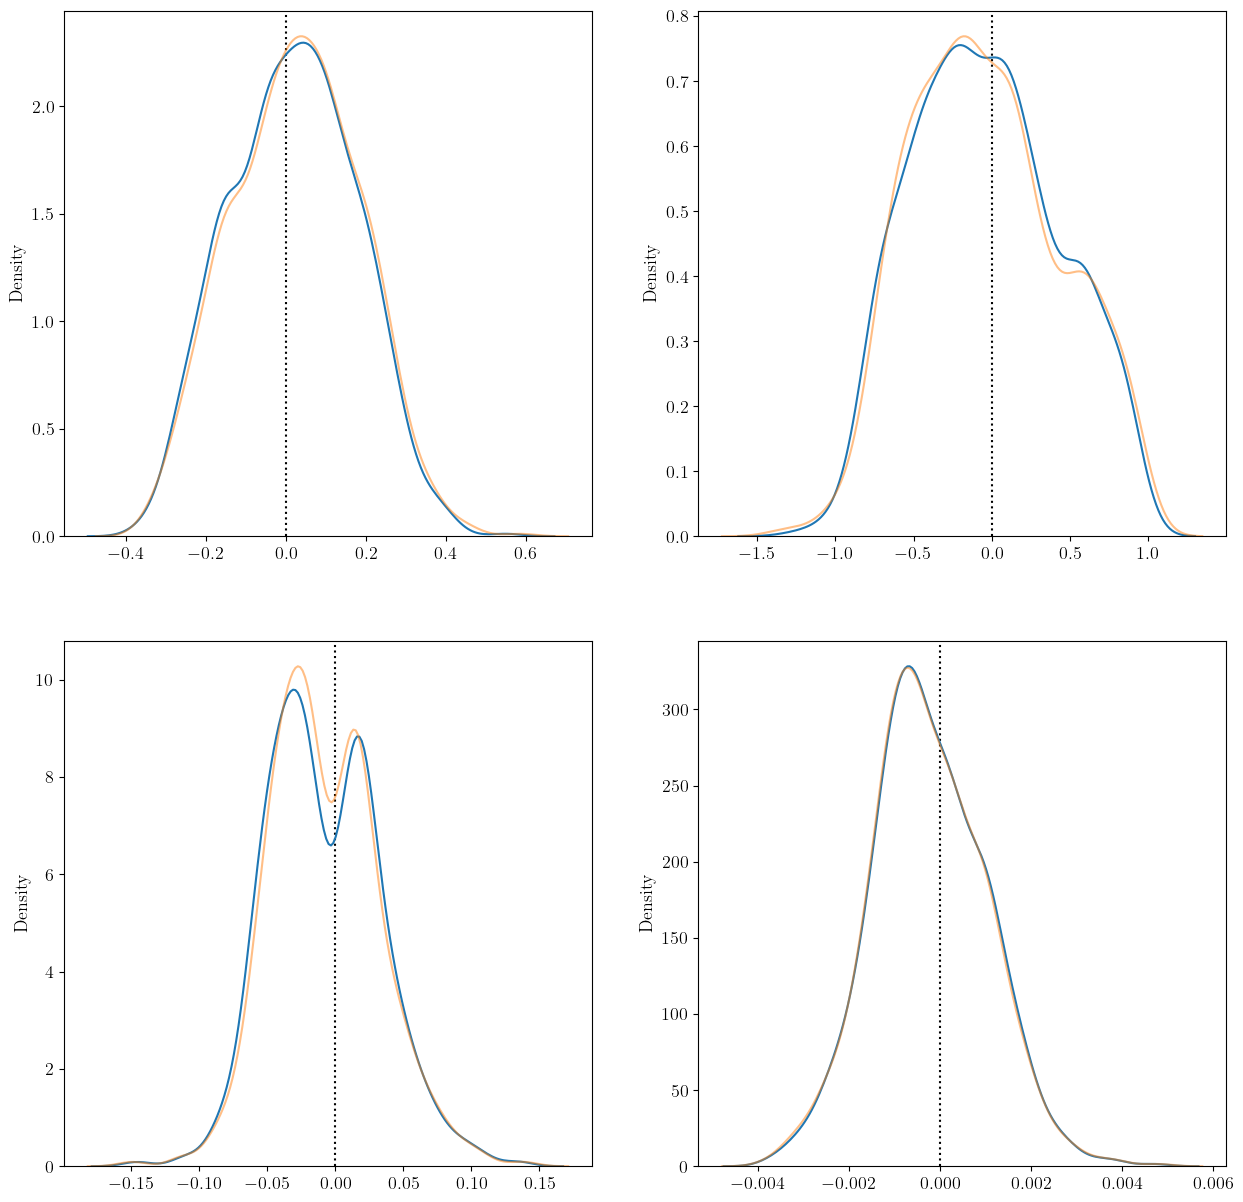

In [11]:
fig, ax = plt.subplots(2,2,figsize=(15, 15))

ax = ax.flatten()

[a.axvline(0.0, color='black', ls=':') for a in ax]

for i in range(4):
    sns.kdeplot(compmeans[:,i] - truths[:,2+i], ax=ax[i])
    sns.kdeplot(medians[:,i] - truths[:,2+i], alpha=.5, ax=ax[i])
# plt.hist(compmeans - truths)

In [14]:
stats_labels = ['sims', 'truths', 'ravg', 'medians', 'low68', 'high68', 'low95', 'high95', 'intervals68', 'intervals95']

In [12]:
biases = (means - truths[:,2:])
# sigma1_68 = np.where(biases > 0, np.abs(intervals68[:,:,0]), intervals68[:,:,1])
# sigma2_68 = np.where(biases > 0, np.abs(stats_v1['intervals68'][:,:,1]), stats_v1['intervals68'][:,:,0])
sigma_max_68 = np.max(np.abs(intervals68), axis=2)
sigma_max_95 = np.max(np.abs(intervals95), axis=2)


# sigma1_95 = np.where(biases > 0, np.abs(stats_v1['intervals95'][:,:,0]), stats_v1['intervals95'][:,:,1])
# sigma2_95 = np.where(biases > 0, np.abs(stats_v1['intervals95'][:,:,1]), stats_v1['intervals95'][:,:,0])
# sigma_max_95 = np.max(np.abs(stats_v1['intervals95']), axis=2)

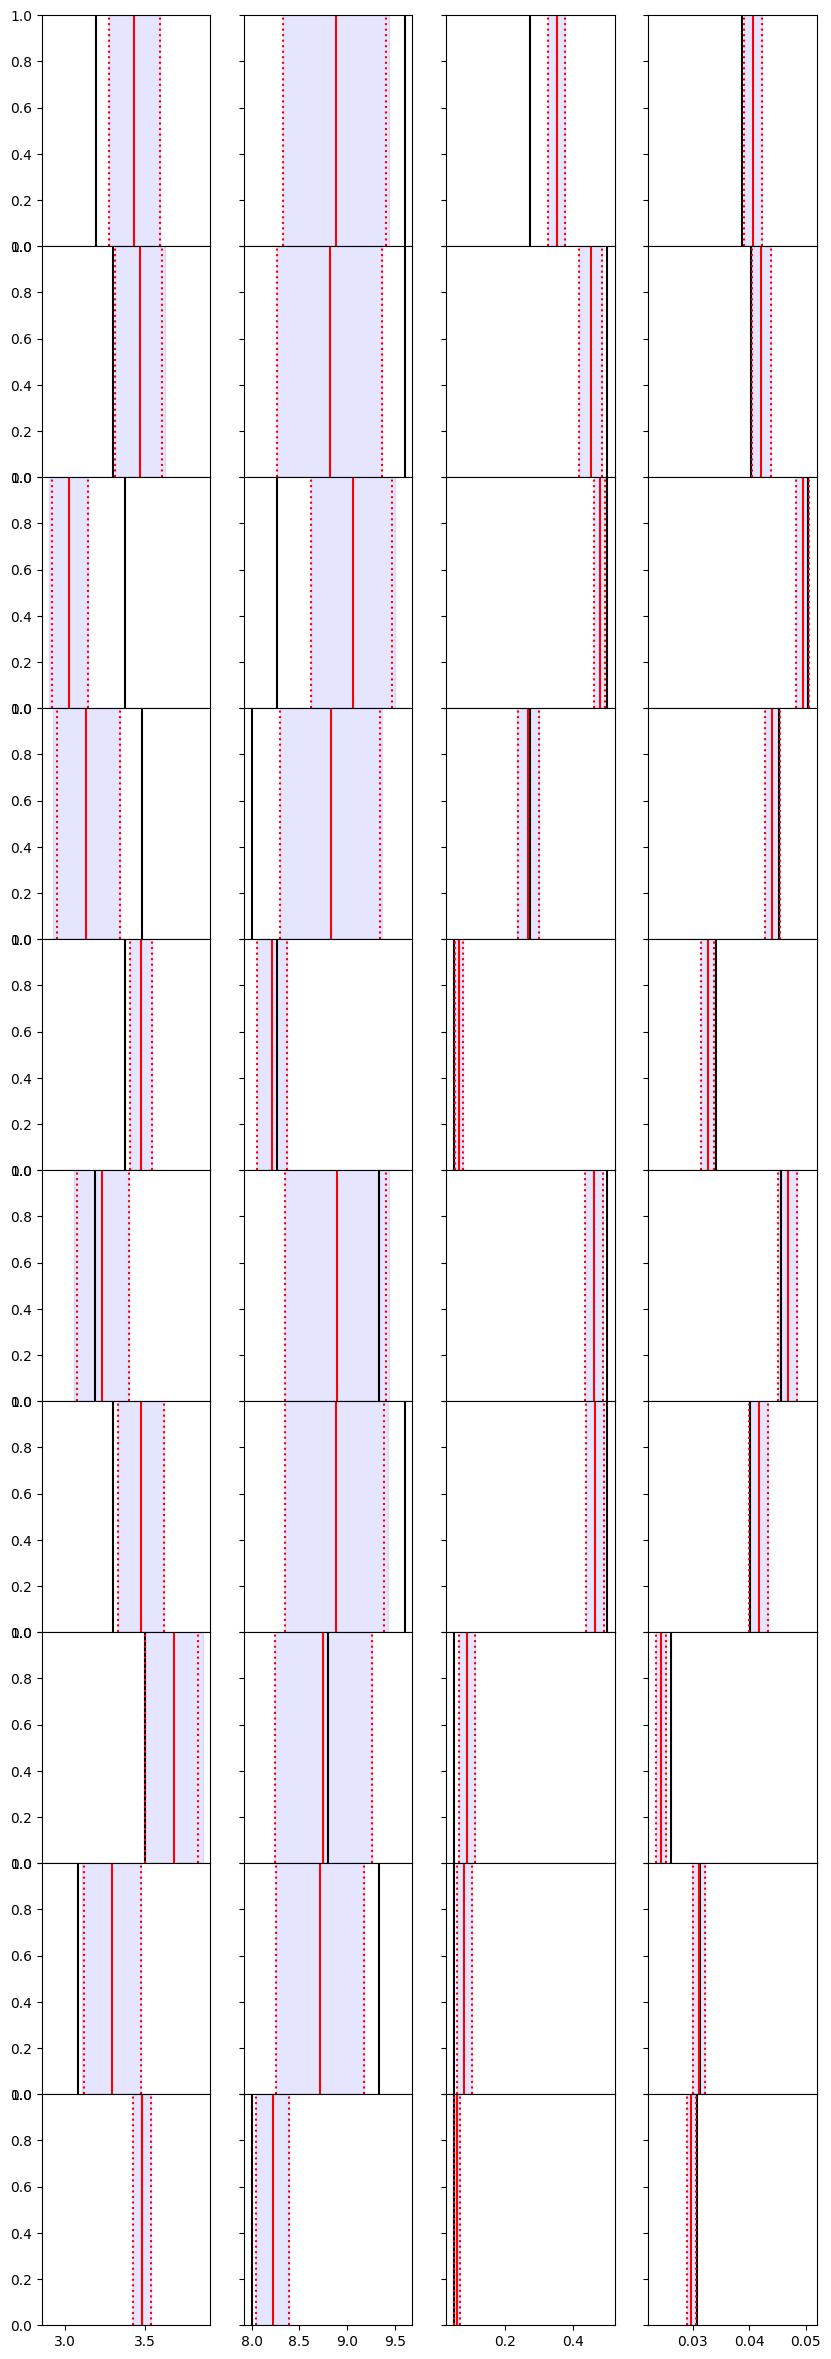

In [10]:
fig, axs = plt.subplots(10,4, sharex='col', sharey=True, figsize=(10,30))
fig.subplots_adjust(hspace=0.0)

for i in range(10):
    ax = axs[i]
    truth = truths[i]
    mean = means[i]
    low68_i = low68[i]
    high68_i = high68[i]
    sigma = sigma_max_68[i]

    for j in range(4):
        t = truth[2+j]
        m = mean[j]
        l = low68_i[j]
        h = high68_i[j]
        s = sigma[j]

        # print(t)
        ax[j].axvline(t, color='black')
        ax[j].axvline(m, color='red')
        ax[j].axvline(l, color='red', ls=':')
        ax[j].axvline(h, color='red', ls=':')
        ax[j].axvspan(m - s, m + s, color='blue', alpha=.1)


In [13]:
plt.rcParams.update({
    "text.usetex": True,  # Use LaTeX for rendering
    'font.size': 13,
    "font.family": "serif",  # Use serif font
    "font.serif": ["Computer Modern Roman"],  # LaTeX's default font
})

In [14]:
astro_wunits = [
    r"$\log{f_X}$",
    r"$r_{\mathrm{H/S}}$",
    r"$\log{[\tau_{\mathrm{SF}}/\mathrm{Gyr}]}$",
    r"$\log{[M_{\mathrm{min}}/M_{\odot}]}$",
    r"$f_{\mathrm{esc}}$",
    r"$\tau_{\mathrm{CMB}}$",
    r"$A_{\mathrm{hkSZ}}$",
]

For parameter $\log{[\tau_{\mathrm{SF}}/\mathrm{Gyr}]}$, the min=-6.72919210298811 and the max=8.25643625601239
For parameter $\log{[M_{\mathrm{min}}/M_{\odot}]}$, the min=-4.645889296324312 and the max=4.726284612266068
For parameter $f_{\mathrm{esc}}$, the min=-3.1913767448133443 and the max=5.136721069334923
For parameter $\tau_{\mathrm{CMB}}$, the min=-3.3733260983191635 and the max=3.285844789739112


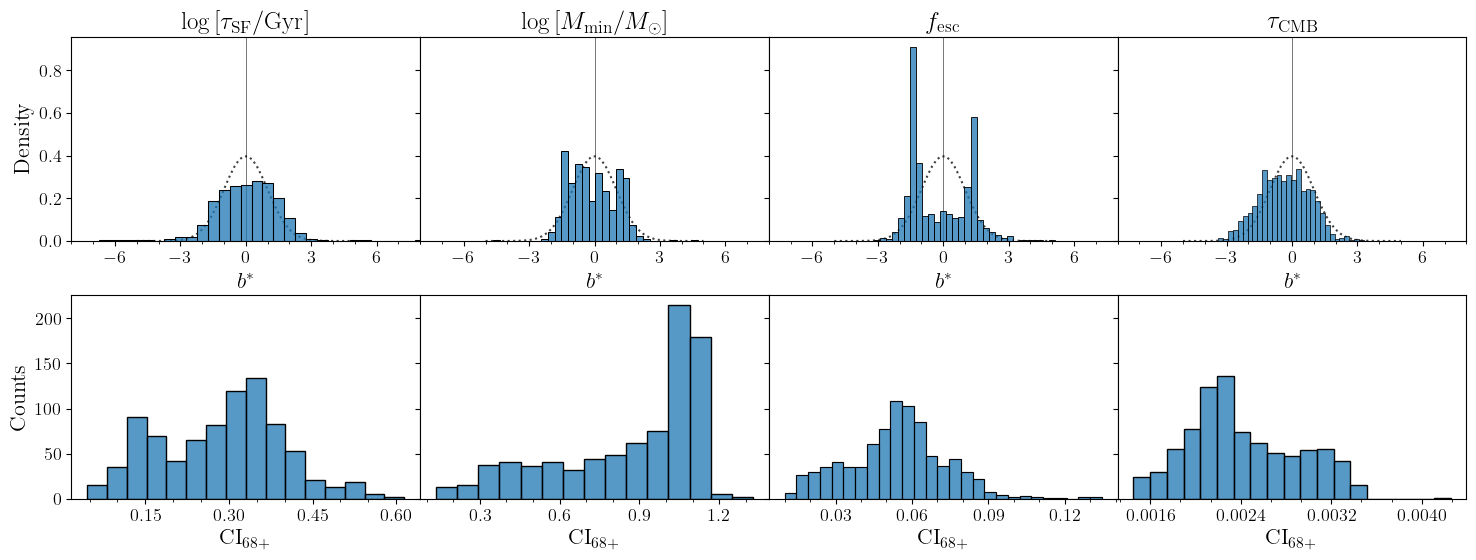

In [17]:
fig, ax = plt.subplots(2,4, sharex=False, sharey='row', figsize=(18,6))
fig.subplots_adjust(wspace=0.0, hspace=.265)

[ax[0,i].axvline(0.0, color='black', alpha=.75, lw=.5, ls='-', zorder=0) for i in range(4)]
# [ax[1,i].axvline(1.0, color='black', alpha=.5) for i in range(4)]


for i, pname in enumerate(astro_wunits[2:-1]):
    ax[0,i].set_title(pname, fontsize=18)

    nb = biases[:,i] / sigma_max_68[:,i]

    x = np.linspace(-5,5)
    ax[0,i].plot(x, np.exp(-.5 * x**2) / np.sqrt(2.0 * np.pi), color='black', alpha=.75, ls=':', zorder=0)


 #   sns.histplot(np.random.normal(size=len(nb)), ax=ax[0,i], stat='density', bins=bins, alpha=.25, color='black')
    sns.histplot(nb, ax=ax[0,i], bins=30, stat='density', alpha=.75)
    print(f"For parameter {pname}, the min={nb.min()} and the max={nb.max()}")
    

    # counts, bin_edges, patches = ax[1,i].hist(2 * sigma_max_68[:,i],
    #                                   bins=bins, density=True, alpha=1.0)

    CI = 2 * sigma_max_68[:,i]  
    sns.histplot(CI, ax=ax[1,i], alpha=.75)

    ax[0,i].set_ylabel('')
    ax[1,i].set_ylabel('')

    ax[0,i].xaxis.set_major_locator(MultipleLocator(3.0))
    ax[0,i].xaxis.set_minor_locator(MultipleLocator(1.0))

    ax[1,i].xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax[1,i].xaxis.set_minor_locator(AutoMinorLocator(3))
    
#     # Split patches into filled and unfilled groups
#     split = 26 # higher than this is 1.0
    
#     # Make the first half filled (with color)
#     for j in range(split):
#         patches[j].set_facecolor(sns.color_palette()[0])
#         patches[j].set_edgecolor(darker)
    
#     # Make the second half unfilled (just borders)
#     for j in range(split, len(patches)):
#         patches[j].set_facecolor('none')
#         patches[j].set_edgecolor(sns.color_palette()[0])

#     # sns.histplot(2 * np.max(np.abs(stats_v2['intervals95']), axis=2)[:,i] / widths[i], stat='density', bins=bins, ax=ax[1,i])
#     mean_CI = 2 * np.mean(np.max(np.abs(stats_v2['intervals95']), axis=2)[:,i] / widths[i])
#     std_CI = 2 * np.std(np.max(np.abs(stats_v2['intervals95']), axis=2)[:,i] / widths[i])
#     ax[1,i].axvline(mean_CI, color=darker)
#     ax[1,i].axvspan(mean_CI - std_CI, mean_CI + std_CI, color=darker, alpha=.15)
# #    ax[1,i].axvspan(1.0, 1.75, color='black', hatch='//', fill=False, alpha=.5, zorder=0)
#     ax[1,i].axvline(fidCI[i] / widths[i], color=sns.color_palette()[1])
#     if i == 3:
#         ax[1,i].axvline((2 * .006) / widths[i], color=sns.color_palette()[2], ls=(0, (5, 1)), lw=.9, alpha=.9)

#     print(f"\t mean_CI={mean_CI:.3f}, std_CI={std_CI:3f}") 
#     print()

[ax[0,i].set_xlabel(r"$b^*$", fontsize=16) for i in range(4)]
[ax[1,i].set_xlabel(r"$\mathrm{CI}_{68+}$", fontsize=16) for i in range(4)]

# ax[0,0].set_ylabel(r"$\hat{p}(\theta)$", fontsize=16)
ax[0,0].set_ylabel(r"Density", fontsize=16)
ax[1,0].set_ylabel(r"Counts", fontsize=16)


[ax[0,i].set_xlim(-8,8) for i in range(4)]
# [ax[0,i].set_ylim(0.0,.95) for i in range(4)]

# [ax[1,i].set_ylim(0.0,225) for i in range(4)]

fig.savefig('biases.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

(-2.95, 2.95)

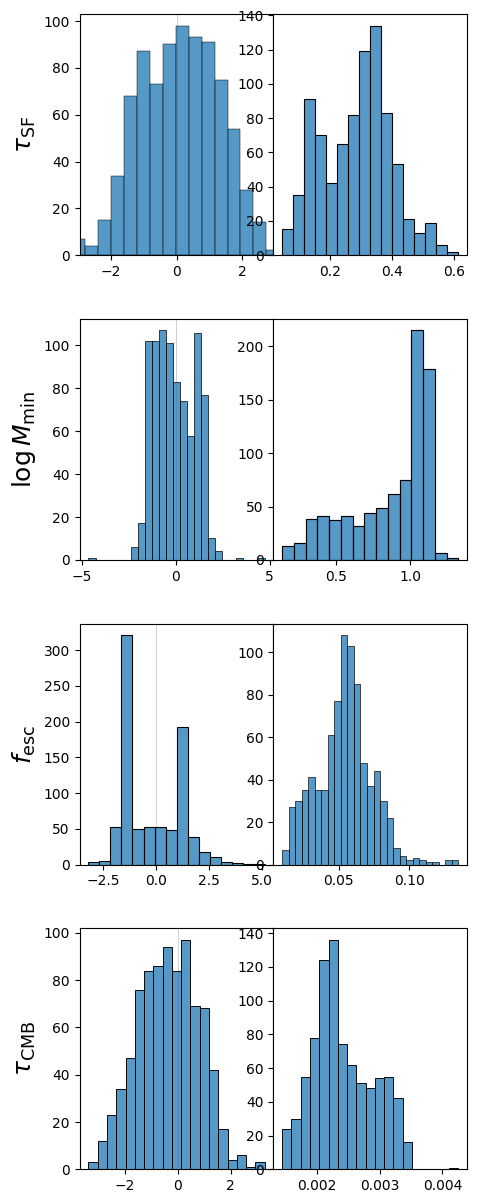

In [44]:
fig, ax = plt.subplots(4,2, sharex=False, sharey=False, figsize=(5,15))
fig.subplots_adjust(wspace=0.0, hspace=.265)

[ax[i,0].axvline(0.0, color='black', alpha=.25, lw=.5, ls='-', zorder=0) for i in range(4)]
# [ax[1,i].axvline(1.0, color='black', alpha=.5) for i in range(4)]

bins = 30

for i, pname in enumerate(astro_pnames_formatted[2:-1]):
    ax[i,0].set_ylabel(pname, fontsize=18)

    nb = biases[:,i] / sigma_max_68[:,i]

    sns.histplot(nb, ax=ax[i,0], label=None, alpha=.75)

    # counts, bin_edges, patches = ax[1,i].hist(2 * sigma_max_68[:,i],
    #                                   bins=bins, density=True, alpha=1.0)

    sns.histplot(2 * sigma_max_68[:,i], ax=ax[i,1], alpha=.75)
    

# [ax[i,0].set_xlabel(r"$b^*$", fontsize=16) for i in range(4)]

# [ax[i,1].set_xlabel(r"$\mathrm{CI}_{68+}$", fontsize=16) for i in range(4)]

# [ax[i,0].set_ylabel("", fontsize=16) for i in range(4)]
[ax[i,1].set_ylabel("", fontsize=16) for i in range(4)]

# ax[0,0].xaxis.set_major_locator(MultipleLocator(1.0))
# ax[0,0].xaxis.set_minor_locator(MultipleLocator(0.5))

ax[0,0].set_xlim(-2.95,2.95)

#fig.savefig('biases.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)